# Imputing Missing Values with Multivariate Gaussians

## Real-World Scenario: Patient Health Records with Missing Lab Results

**From PML Chapter 3.2.5**

A hospital has patient health records with multiple correlated measurements:
- Blood pressure (systolic)
- Cholesterol level
- Blood glucose
- BMI (Body Mass Index)
- Heart rate

Unfortunately, not all patients have all measurements recorded. Some missed appointments, some tests weren't ordered, etc. We want to **impute (fill in) the missing values** using the correlations between the measurements.

The key insight from PML 3.2.5: If we model the measurements as a multivariate Gaussian, we can use the **conditional distribution** to predict missing values given observed ones.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
import pandas as pd

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
%matplotlib inline

## Key Formula from PML 3.2.5

For a jointly Gaussian vector $\mathbf{y} = (\mathbf{y}_v, \mathbf{y}_h)$ where:
- $\mathbf{y}_v$ = **visible** (observed) variables
- $\mathbf{y}_h$ = **hidden** (missing) variables

The conditional distribution of the hidden given the visible is:

$$p(\mathbf{y}_h | \mathbf{y}_v, \boldsymbol{\theta}) = \mathcal{N}(\mathbf{y}_h | \boldsymbol{\mu}_{h|v}, \boldsymbol{\Sigma}_{h|v})$$

where:
$$\boldsymbol{\mu}_{h|v} = \boldsymbol{\mu}_h + \boldsymbol{\Sigma}_{hv} \boldsymbol{\Sigma}_{vv}^{-1} (\mathbf{y}_v - \boldsymbol{\mu}_v)$$
$$\boldsymbol{\Sigma}_{h|v} = \boldsymbol{\Sigma}_{hh} - \boldsymbol{\Sigma}_{hv} \boldsymbol{\Sigma}_{vv}^{-1} \boldsymbol{\Sigma}_{vh}$$

**The posterior mean $\boldsymbol{\mu}_{h|v}$ is our best estimate for the missing values.**

## Step 1: Define the Health Measurements Model

We model 5 health measurements as a 5D Gaussian with realistic correlations.

In [2]:
# Variable indices
BP = 0        # Blood pressure (systolic, mmHg)
CHOL = 1      # Cholesterol (mg/dL)
GLUC = 2      # Blood glucose (mg/dL)
BMI = 3       # Body Mass Index (kg/m^2)
HR = 4        # Heart rate (bpm)

variable_names = ['Blood Pressure', 'Cholesterol', 'Glucose', 'BMI', 'Heart Rate']
variable_units = ['mmHg', 'mg/dL', 'mg/dL', 'kg/m²', 'bpm']

# Mean values (typical healthy adult)
mu = np.array([120.0,   # BP: 120 mmHg (systolic)
               200.0,   # Cholesterol: 200 mg/dL
               100.0,   # Glucose: 100 mg/dL (fasting)
               25.0,    # BMI: 25 kg/m²
               72.0])   # Heart rate: 72 bpm

# Standard deviations
sigmas = np.array([15.0,   # BP: std of 15 mmHg
                   35.0,   # Cholesterol: std of 35 mg/dL
                   15.0,   # Glucose: std of 15 mg/dL
                   4.0,    # BMI: std of 4 kg/m²
                   10.0])  # Heart rate: std of 10 bpm

print("Health Measurements Model")
print("=" * 50)
print(f"{'Variable':<20} {'Mean':>10} {'Std':>10} {'Unit':<10}")
print("-" * 50)
for name, m, s, u in zip(variable_names, mu, sigmas, variable_units):
    print(f"{name:<20} {m:>10.1f} {s:>10.1f} {u:<10}")

Health Measurements Model
Variable                   Mean        Std Unit      
--------------------------------------------------
Blood Pressure            120.0       15.0 mmHg      
Cholesterol               200.0       35.0 mg/dL     
Glucose                   100.0       15.0 mg/dL     
BMI                        25.0        4.0 kg/m²     
Heart Rate                 72.0       10.0 bpm       


In [3]:
# Correlation matrix (based on medical literature)
# These correlations reflect real physiological relationships:
#   - BMI correlates with BP, cholesterol, glucose (metabolic syndrome)
#   - BP correlates with heart rate
#   - Cholesterol and glucose are both metabolic markers

#              BP    Chol   Gluc   BMI    HR
R = np.array([[1.00, 0.30,  0.25,  0.40,  0.35],   # BP
              [0.30, 1.00,  0.35,  0.45,  0.15],   # Cholesterol
              [0.25, 0.35,  1.00,  0.50,  0.20],   # Glucose
              [0.40, 0.45,  0.50,  1.00,  0.10],   # BMI
              [0.35, 0.15,  0.20,  0.10,  1.00]])  # Heart Rate

# Build covariance matrix: Σ = D @ R @ D where D = diag(sigmas)
D = np.diag(sigmas)
Sigma = D @ R @ D

print("Correlation Matrix:")
print("         ", "  ".join(f"{name[:4]:>6}" for name in variable_names))
for i, name in enumerate(variable_names):
    print(f"{name[:4]:>6}  ", "  ".join(f"{R[i,j]:>6.2f}" for j in range(5)))

Correlation Matrix:
            Bloo    Chol    Gluc     BMI    Hear
  Bloo     1.00    0.30    0.25    0.40    0.35
  Chol     0.30    1.00    0.35    0.45    0.15
  Gluc     0.25    0.35    1.00    0.50    0.20
   BMI     0.40    0.45    0.50    1.00    0.10
  Hear     0.35    0.15    0.20    0.10    1.00


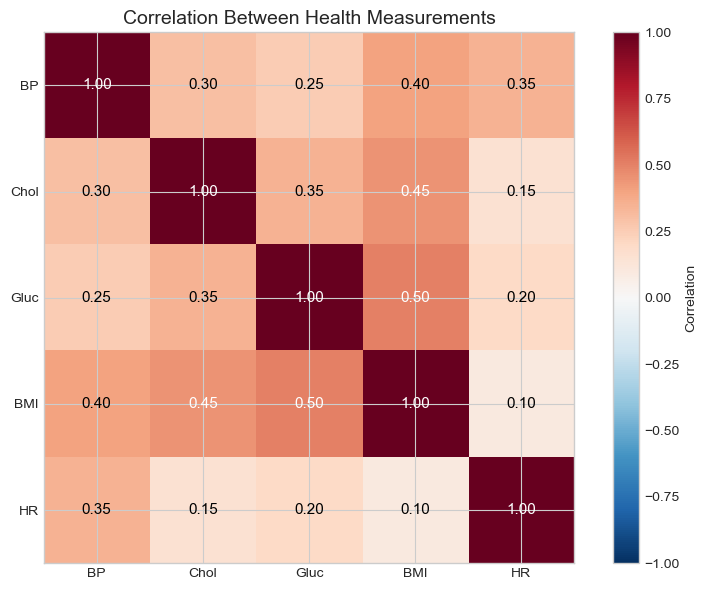

In [4]:
# Visualize correlation matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(R, cmap='RdBu_r', vmin=-1, vmax=1)

for i in range(5):
    for j in range(5):
        color = 'white' if abs(R[i,j]) > 0.4 else 'black'
        ax.text(j, i, f"{R[i,j]:.2f}", ha='center', va='center', 
                color=color, fontsize=11)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
short_names = ['BP', 'Chol', 'Gluc', 'BMI', 'HR']
ax.set_xticklabels(short_names)
ax.set_yticklabels(short_names)
plt.colorbar(im, label='Correlation')
plt.title('Correlation Between Health Measurements', fontsize=14)
plt.tight_layout()
plt.show()

## Step 2: Generate Complete Patient Data

First, let's generate a "complete" dataset (no missing values) to serve as ground truth.

In [5]:
# Generate 20 complete patient records
n_patients = 20
complete_data = np.random.multivariate_normal(mu, Sigma, n_patients)

# Create a DataFrame for nice display
df_complete = pd.DataFrame(complete_data, columns=short_names)
df_complete.index.name = 'Patient'

print("Complete Patient Records (Ground Truth)")
print("=" * 60)
print(df_complete.round(1).head(10))

Complete Patient Records (Ground Truth)
            BP   Chol   Gluc   BMI    HR
Patient                                 
0        116.2  183.9   87.9  21.7  84.3
1        146.2  202.6  107.2  29.2  77.3
2        125.0  217.9   98.3  21.2  54.7
3        117.0  223.6   92.7  20.9  60.9
4        113.9  149.7   89.1  21.1  56.1
5        111.0  200.6   86.0  22.5  61.9
6        147.1  213.7  120.4  32.0  73.1
7        118.2  240.2  131.0  30.3  61.0
8        118.1  173.7   98.6  19.5  68.4
9        126.2  227.7   89.9  19.6  75.6


## Step 3: Introduce Missing Values

In real medical data, values are often missing. Let's randomly hide some measurements.

In [6]:
# Create a mask for missing values (True = missing)
# Each entry has 30% chance of being missing
np.random.seed(123)  # Different seed for missingness pattern
missing_prob = 0.30
missing_mask = np.random.random((n_patients, 5)) < missing_prob

# Ensure at least one value is observed per patient
for i in range(n_patients):
    if missing_mask[i].all():  # All missing
        # Keep at least one random variable
        keep_idx = np.random.randint(5)
        missing_mask[i, keep_idx] = False

# Create observed data (with NaN for missing)
observed_data = complete_data.copy()
observed_data[missing_mask] = np.nan

df_observed = pd.DataFrame(observed_data, columns=short_names)
df_observed.index.name = 'Patient'

print("Observed Patient Records (with missing values shown as NaN)")
print("=" * 60)
print(df_observed.round(1).head(10))

# Count missing values
n_missing = missing_mask.sum()
n_total = n_patients * 5
print(f"\nTotal missing values: {n_missing} out of {n_total} ({100*n_missing/n_total:.1f}%)")

Observed Patient Records (with missing values shown as NaN)
            BP   Chol   Gluc   BMI    HR
Patient                                 
0        116.2    NaN    NaN  21.7  84.3
1        146.2  202.6  107.2  29.2  77.3
2        125.0  217.9   98.3   NaN  54.7
3        117.0    NaN    NaN  20.9  60.9
4        113.9  149.7   89.1  21.1  56.1
5        111.0  200.6    NaN   NaN  61.9
6          NaN  213.7  120.4  32.0  73.1
7        118.2  240.2  131.0  30.3  61.0
8        118.1    NaN   98.6  19.5  68.4
9          NaN  227.7   89.9  19.6  75.6

Total missing values: 21 out of 100 (21.0%)


## Step 4: Implement Missing Value Imputation

Now we implement the key formula from PML 3.2.5 to impute missing values.

In [7]:
def impute_missing(y_observed, missing_mask_row, mu, Sigma):
    """
    Impute missing values using MVN conditional distribution.
    
    From PML Eq. 3.28:
    μ_{h|v} = μ_h + Σ_hv @ Σ_vv^{-1} @ (y_v - μ_v)
    Σ_{h|v} = Σ_hh - Σ_hv @ Σ_vv^{-1} @ Σ_vh
    
    Parameters:
    -----------
    y_observed : array, observed values (with NaN for missing)
    missing_mask_row : array of bool, True where value is missing
    mu : array, mean vector of the MVN
    Sigma : array, covariance matrix of the MVN
    
    Returns:
    --------
    y_imputed : array, with missing values filled in
    mu_hidden : array, posterior mean of hidden variables
    Sigma_hidden : array, posterior covariance of hidden variables
    """
    # Identify visible and hidden indices
    hidden_idx = np.where(missing_mask_row)[0]
    visible_idx = np.where(~missing_mask_row)[0]
    
    if len(hidden_idx) == 0:
        # Nothing to impute
        return y_observed.copy(), np.array([]), np.array([[]])
    
    if len(visible_idx) == 0:
        # Nothing observed - use prior
        y_imputed = mu.copy()
        return y_imputed, mu, Sigma
    
    # Extract observed values
    y_v = y_observed[visible_idx]
    
    # Extract mean components
    mu_h = mu[hidden_idx]
    mu_v = mu[visible_idx]
    
    # Extract covariance blocks
    Sigma_hh = Sigma[np.ix_(hidden_idx, hidden_idx)]
    Sigma_hv = Sigma[np.ix_(hidden_idx, visible_idx)]
    Sigma_vh = Sigma[np.ix_(visible_idx, hidden_idx)]
    Sigma_vv = Sigma[np.ix_(visible_idx, visible_idx)]
    
    # Compute Σ_vv^{-1}
    Sigma_vv_inv = np.linalg.inv(Sigma_vv)
    
    # Conditional mean: μ_h + Σ_hv @ Σ_vv^{-1} @ (y_v - μ_v)
    mu_hidden = mu_h + Sigma_hv @ Sigma_vv_inv @ (y_v - mu_v)
    
    # Conditional covariance: Σ_hh - Σ_hv @ Σ_vv^{-1} @ Σ_vh
    Sigma_hidden = Sigma_hh - Sigma_hv @ Sigma_vv_inv @ Sigma_vh
    
    # Fill in the imputed values
    y_imputed = y_observed.copy()
    y_imputed[hidden_idx] = mu_hidden
    
    return y_imputed, mu_hidden, Sigma_hidden

## Step 5: Apply Imputation to All Patients

In [8]:
# Impute missing values for all patients
imputed_data = np.zeros_like(observed_data)
imputation_uncertainties = []  # Store uncertainty for each imputation

for i in range(n_patients):
    y_obs = observed_data[i].copy()
    mask = missing_mask[i]
    
    y_imp, mu_h, Sigma_h = impute_missing(y_obs, mask, mu, Sigma)
    imputed_data[i] = y_imp
    
    # Store uncertainties (std devs) for missing values
    if len(mu_h) > 0:
        stds = np.sqrt(np.diag(Sigma_h))
        imputation_uncertainties.append({
            'patient': i,
            'hidden_idx': np.where(mask)[0],
            'stds': stds
        })

df_imputed = pd.DataFrame(imputed_data, columns=short_names)
df_imputed.index.name = 'Patient'

In [9]:
# Compare: Truth vs Observed vs Imputed for first 10 patients
print("Comparison: Ground Truth vs Observed vs Imputed")
print("=" * 80)

for i in range(min(10, n_patients)):
    print(f"\nPatient {i}:")
    print(f"  {'Variable':<15} {'Truth':>10} {'Observed':>12} {'Imputed':>10} {'Error':>10}")
    print("  " + "-" * 60)
    
    for j, name in enumerate(short_names):
        truth = complete_data[i, j]
        obs = observed_data[i, j]
        imp = imputed_data[i, j]
        
        if missing_mask[i, j]:
            # This was missing and imputed
            error = imp - truth
            print(f"  {name:<15} {truth:>10.1f} {'MISSING':>12} {imp:>10.1f} {error:>+10.1f} *")
        else:
            # This was observed
            print(f"  {name:<15} {truth:>10.1f} {obs:>12.1f} {imp:>10.1f} {'---':>10}")

print("\n* = imputed value (was missing)")

Comparison: Ground Truth vs Observed vs Imputed

Patient 0:
  Variable             Truth     Observed    Imputed      Error
  ------------------------------------------------------------
  BP                   116.2        116.2      116.2        ---
  Chol                 183.9      MISSING      190.4       +6.5 *
  Gluc                  87.9      MISSING       96.7       +8.8 *
  BMI                   21.7         21.7       21.7        ---
  HR                    84.3         84.3       84.3        ---

Patient 1:
  Variable             Truth     Observed    Imputed      Error
  ------------------------------------------------------------
  BP                   146.2        146.2      146.2        ---
  Chol                 202.6        202.6      202.6        ---
  Gluc                 107.2        107.2      107.2        ---
  BMI                   29.2         29.2       29.2        ---
  HR                    77.3         77.3       77.3        ---

Patient 2:
  Variable        

## Step 6: Evaluate Imputation Quality

In [10]:
# Compute imputation errors (only for actually missing values)
errors = imputed_data[missing_mask] - complete_data[missing_mask]

print("Imputation Error Statistics")
print("=" * 50)
print(f"Number of imputed values: {len(errors)}")
print(f"Mean error (bias): {errors.mean():.2f}")
print(f"Std of errors: {errors.std():.2f}")
print(f"Mean absolute error: {np.abs(errors).mean():.2f}")
print(f"RMSE: {np.sqrt((errors**2).mean()):.2f}")

# Per-variable error analysis
print("\nPer-Variable Imputation Performance:")
print("-" * 50)
print(f"{'Variable':<15} {'N Missing':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 50)

for j, name in enumerate(short_names):
    var_mask = missing_mask[:, j]
    n_missing_var = var_mask.sum()
    if n_missing_var > 0:
        var_errors = imputed_data[var_mask, j] - complete_data[var_mask, j]
        mae = np.abs(var_errors).mean()
        rmse = np.sqrt((var_errors**2).mean())
        print(f"{name:<15} {n_missing_var:>10} {mae:>10.2f} {rmse:>10.2f}")
    else:
        print(f"{name:<15} {0:>10} {'N/A':>10} {'N/A':>10}")

Imputation Error Statistics
Number of imputed values: 21
Mean error (bias): -3.42
Std of errors: 15.17
Mean absolute error: 11.22
RMSE: 15.55

Per-Variable Imputation Performance:
--------------------------------------------------
Variable         N Missing        MAE       RMSE
--------------------------------------------------
BP                       5      13.35      14.85
Chol                     4      23.40      28.15
Gluc                     6       6.79       8.33
BMI                      5       3.34       3.90
HR                       1      17.76      17.76


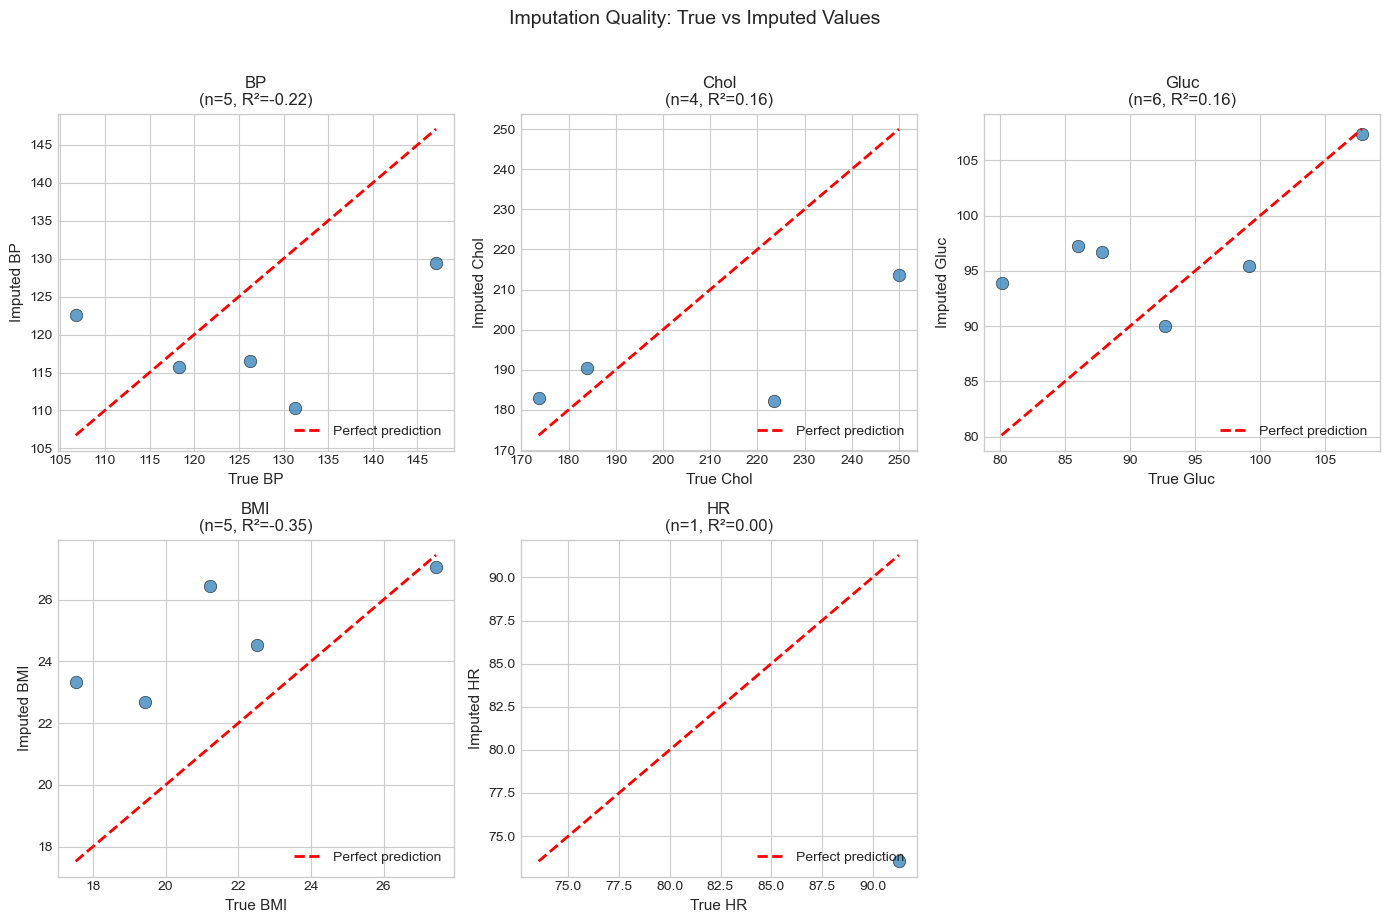

In [11]:
# Visualize imputation quality
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for j, (name, ax) in enumerate(zip(short_names, axes[:5])):
    var_mask = missing_mask[:, j]
    
    if var_mask.sum() > 0:
        truth = complete_data[var_mask, j]
        imputed = imputed_data[var_mask, j]
        
        ax.scatter(truth, imputed, alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
        
        # Perfect prediction line
        min_val = min(truth.min(), imputed.min())
        max_val = max(truth.max(), imputed.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
                label='Perfect prediction')
        
        # Calculate R²
        ss_res = ((imputed - truth) ** 2).sum()
        ss_tot = ((truth - truth.mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        
        ax.set_xlabel(f'True {name}', fontsize=11)
        ax.set_ylabel(f'Imputed {name}', fontsize=11)
        ax.set_title(f'{name}\n(n={var_mask.sum()}, R²={r2:.2f})', fontsize=12)
        ax.legend(loc='lower right')
    else:
        ax.text(0.5, 0.5, 'No missing\nvalues', ha='center', va='center', fontsize=14)
        ax.set_title(name)

# Hide the 6th subplot
axes[5].axis('off')

plt.suptitle('Imputation Quality: True vs Imputed Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 7: Visualize the Imputation with Uncertainty

A key advantage of the Bayesian approach: we get **uncertainty estimates** for our imputations!

In [12]:
# Detailed example: Patient 0
patient_idx = 0

print(f"Detailed Imputation Analysis for Patient {patient_idx}")
print("=" * 70)

y_obs = observed_data[patient_idx].copy()
mask = missing_mask[patient_idx]
y_imp, mu_h, Sigma_h = impute_missing(y_obs, mask, mu, Sigma)

hidden_idx = np.where(mask)[0]
visible_idx = np.where(~mask)[0]

print("\nObserved variables:")
for idx in visible_idx:
    print(f"  {variable_names[idx]}: {y_obs[idx]:.1f} {variable_units[idx]}")

print("\nMissing variables (imputed with uncertainty):")
if len(hidden_idx) > 0:
    stds = np.sqrt(np.diag(Sigma_h))
    for i, idx in enumerate(hidden_idx):
        true_val = complete_data[patient_idx, idx]
        imp_val = mu_h[i]
        std = stds[i]
        ci_low = imp_val - 1.96 * std
        ci_high = imp_val + 1.96 * std
        
        print(f"  {variable_names[idx]}:")
        print(f"    Imputed: {imp_val:.1f} ± {std:.1f} {variable_units[idx]}")
        print(f"    95% CI: [{ci_low:.1f}, {ci_high:.1f}]")
        print(f"    True value: {true_val:.1f} (error: {imp_val - true_val:+.1f})")
        in_ci = ci_low <= true_val <= ci_high
        print(f"    True value in 95% CI? {'Yes ✓' if in_ci else 'No ✗'}")
else:
    print("  (No missing values for this patient)")

Detailed Imputation Analysis for Patient 0

Observed variables:
  Blood Pressure: 116.2 mmHg
  BMI: 21.7 kg/m²
  Heart Rate: 84.3 bpm

Missing variables (imputed with uncertainty):
  Cholesterol:
    Imputed: 190.4 ± 30.8 mg/dL
    95% CI: [130.0, 250.8]
    True value: 183.9 (error: +6.5)
    True value in 95% CI? Yes ✓
  Glucose:
    Imputed: 96.7 ± 12.8 mg/dL
    95% CI: [71.6, 121.8]
    True value: 87.9 (error: +8.8)
    True value in 95% CI? Yes ✓


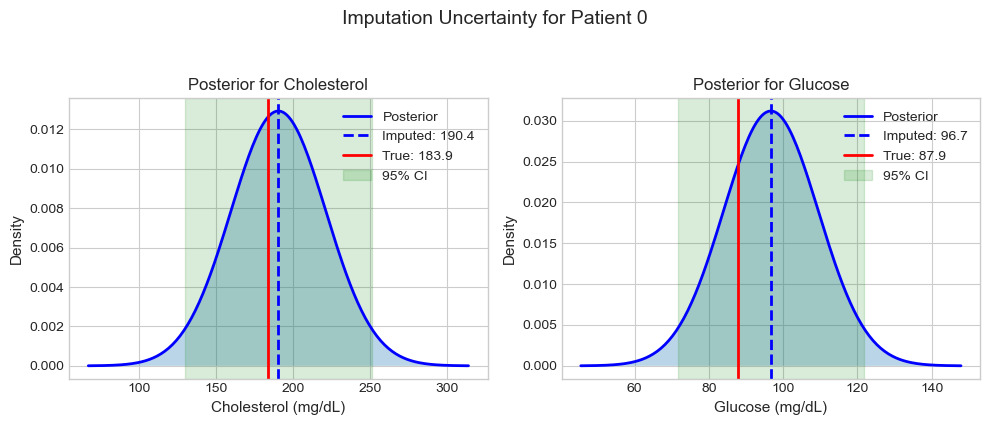

In [13]:
# Visualize uncertainty for a specific patient
patient_idx = 0
y_obs = observed_data[patient_idx].copy()
mask = missing_mask[patient_idx]
y_imp, mu_h, Sigma_h = impute_missing(y_obs, mask, mu, Sigma)

hidden_idx = np.where(mask)[0]

if len(hidden_idx) > 0:
    fig, axes = plt.subplots(1, len(hidden_idx), figsize=(5*len(hidden_idx), 4))
    if len(hidden_idx) == 1:
        axes = [axes]
    
    stds = np.sqrt(np.diag(Sigma_h))
    
    for i, (idx, ax) in enumerate(zip(hidden_idx, axes)):
        imp_val = mu_h[i]
        std = stds[i]
        true_val = complete_data[patient_idx, idx]
        
        # Plot the posterior distribution
        x_range = np.linspace(imp_val - 4*std, imp_val + 4*std, 200)
        pdf = stats.norm.pdf(x_range, imp_val, std)
        
        ax.plot(x_range, pdf, 'b-', linewidth=2, label='Posterior')
        ax.fill_between(x_range, pdf, alpha=0.3)
        
        # Mark the imputed value
        ax.axvline(imp_val, color='blue', linestyle='--', linewidth=2,
                   label=f'Imputed: {imp_val:.1f}')
        
        # Mark the true value
        ax.axvline(true_val, color='red', linestyle='-', linewidth=2,
                   label=f'True: {true_val:.1f}')
        
        # Mark 95% CI
        ci_low = imp_val - 1.96 * std
        ci_high = imp_val + 1.96 * std
        ax.axvspan(ci_low, ci_high, alpha=0.15, color='green', label='95% CI')
        
        ax.set_xlabel(f'{variable_names[idx]} ({variable_units[idx]})', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'Posterior for {variable_names[idx]}', fontsize=12)
        ax.legend(loc='upper right')
    
    plt.suptitle(f'Imputation Uncertainty for Patient {patient_idx}', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print(f"Patient {patient_idx} has no missing values.")

## Step 8: Compare Different Imputation Strategies

Let's compare MVN imputation against simpler approaches.

In [14]:
def mean_imputation(observed_data, missing_mask, mu):
    """Simple imputation: replace missing with population mean."""
    imputed = observed_data.copy()
    for j in range(observed_data.shape[1]):
        imputed[missing_mask[:, j], j] = mu[j]
    return imputed

def column_mean_imputation(observed_data, missing_mask):
    """Replace missing with observed column mean."""
    imputed = observed_data.copy()
    for j in range(observed_data.shape[1]):
        col_mask = missing_mask[:, j]
        if col_mask.any():
            observed_mean = np.nanmean(observed_data[:, j])
            imputed[col_mask, j] = observed_mean
    return imputed

# Apply different imputation methods
imputed_mean = mean_imputation(observed_data, missing_mask, mu)
imputed_col_mean = column_mean_imputation(observed_data, missing_mask)

# Calculate RMSE for each method
methods = {
    'Population Mean': imputed_mean,
    'Column Mean': imputed_col_mean,
    'MVN Conditional': imputed_data
}

print("Comparison of Imputation Methods")
print("=" * 60)
print(f"{'Method':<25} {'RMSE':>10} {'MAE':>10} {'Bias':>10}")
print("-" * 60)

for name, imp in methods.items():
    errors = imp[missing_mask] - complete_data[missing_mask]
    rmse = np.sqrt((errors**2).mean())
    mae = np.abs(errors).mean()
    bias = errors.mean()
    print(f"{name:<25} {rmse:>10.2f} {mae:>10.2f} {bias:>+10.2f}")

Comparison of Imputation Methods
Method                          RMSE        MAE       Bias
------------------------------------------------------------
Population Mean                17.49      13.27      -0.80
Column Mean                    18.53      14.13      +0.21
MVN Conditional                15.55      11.22      -3.42


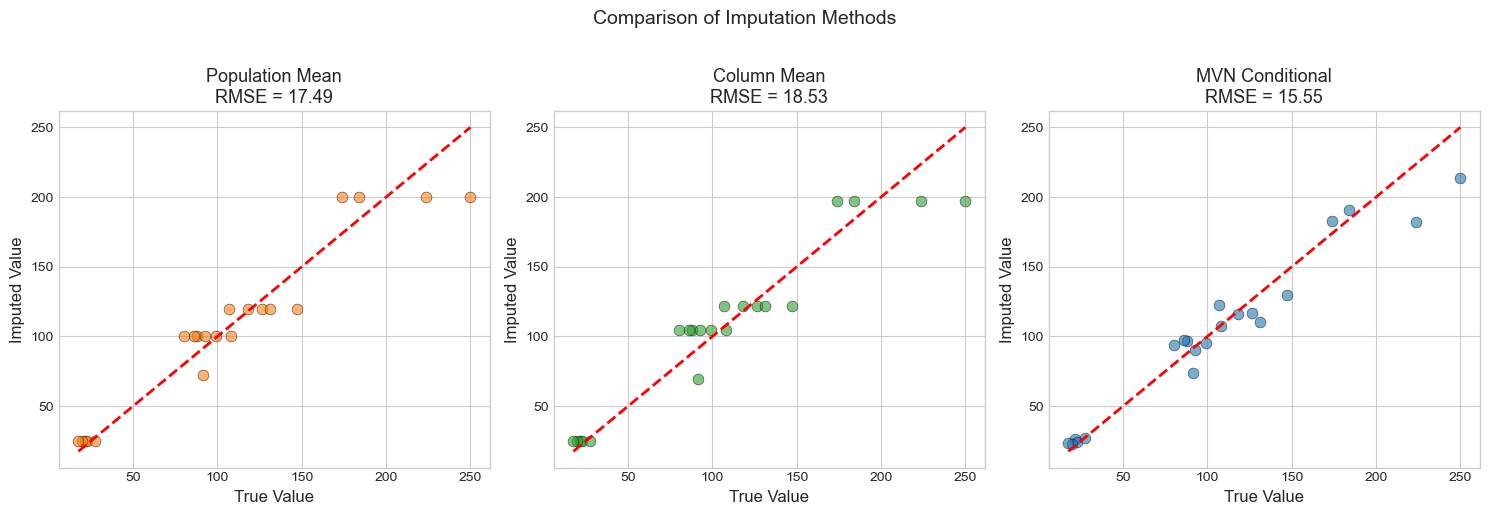

In [15]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

method_names = list(methods.keys())
colors = ['#ff7f0e', '#2ca02c', '#1f77b4']

for ax, (name, imp), color in zip(axes, methods.items(), colors):
    truth = complete_data[missing_mask]
    predicted = imp[missing_mask]
    
    ax.scatter(truth, predicted, alpha=0.6, s=60, color=color, edgecolors='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(truth.min(), predicted.min())
    max_val = max(truth.max(), predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    
    # Calculate RMSE
    rmse = np.sqrt(((predicted - truth)**2).mean())
    
    ax.set_xlabel('True Value', fontsize=12)
    ax.set_ylabel('Imputed Value', fontsize=12)
    ax.set_title(f'{name}\nRMSE = {rmse:.2f}', fontsize=13)

plt.suptitle('Comparison of Imputation Methods', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 9: Hinton Diagram Visualization (as in PML Figure 3.7)

Let's create a visualization similar to Figure 3.7 in the PML book.

In [16]:
def hinton_diagram(matrix, max_val=None, ax=None, title=''):
    """
    Draw a Hinton diagram (squares sized by value magnitude, colored by sign).
    Blue = positive, Red = negative.
    """
    if ax is None:
        fig, ax = plt.subplots()
    
    if max_val is None:
        max_val = np.nanmax(np.abs(matrix))
    
    ax.set_aspect('equal')
    ax.patch.set_facecolor('lightgray')
    
    for (y, x), val in np.ndenumerate(matrix):
        if np.isnan(val):
            continue
        color = 'steelblue' if val >= 0 else 'firebrick'
        size = np.sqrt(np.abs(val) / max_val) * 0.8
        rect = plt.Rectangle([x - size/2, y - size/2], size, size,
                             facecolor=color, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
    
    ax.set_xlim(-0.5, matrix.shape[1] - 0.5)
    ax.set_ylim(matrix.shape[0] - 0.5, -0.5)
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
    ax.set_title(title, fontsize=12)
    
    return ax

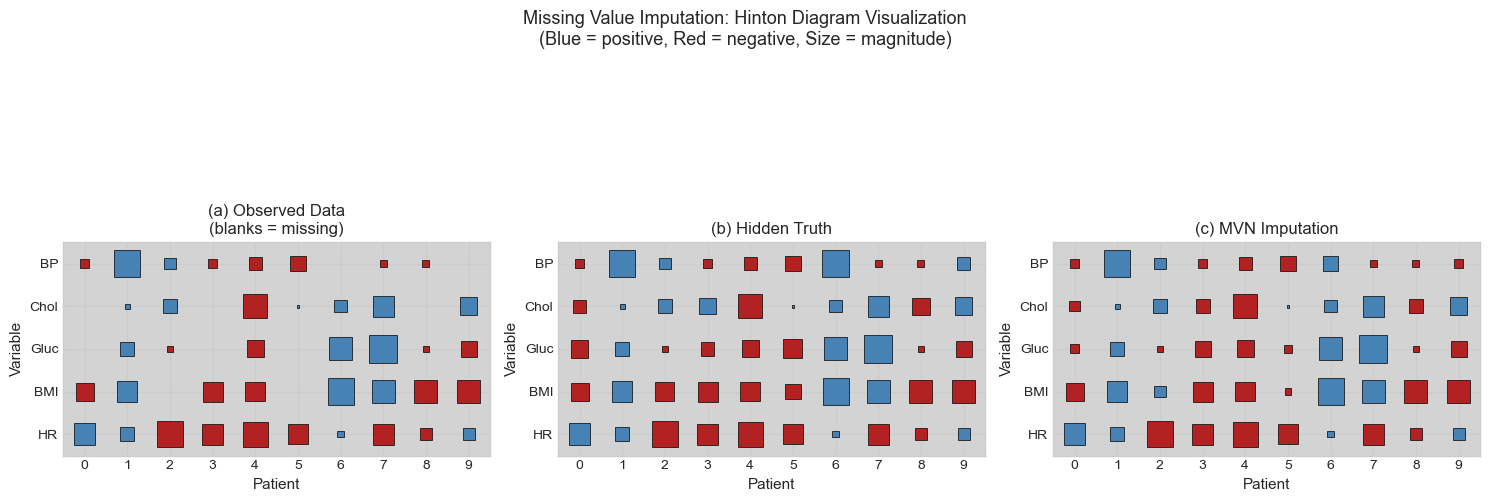

In [17]:
# Normalize data for visualization (center and scale)
def normalize_data(data, mu, sigmas):
    return (data - mu) / sigmas

# Select first 10 patients for visualization
n_show = 10

# Normalize all datasets
obs_norm = normalize_data(observed_data[:n_show], mu, sigmas)
truth_norm = normalize_data(complete_data[:n_show], mu, sigmas)
imp_norm = normalize_data(imputed_data[:n_show], mu, sigmas)

# Set NaN in observed to NaN (for visualization)
obs_norm[missing_mask[:n_show]] = np.nan

# Create figure with three Hinton diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

max_val = 3  # Clip at 3 std devs for visualization

hinton_diagram(obs_norm.T, max_val=max_val, ax=axes[0], title='(a) Observed Data\n(blanks = missing)')
hinton_diagram(truth_norm.T, max_val=max_val, ax=axes[1], title='(b) Hidden Truth')
hinton_diagram(imp_norm.T, max_val=max_val, ax=axes[2], title='(c) MVN Imputation')

# Add labels
for ax in axes:
    ax.set_xlabel('Patient', fontsize=11)
    ax.set_ylabel('Variable', fontsize=11)
    ax.set_yticklabels(short_names)

plt.suptitle('Missing Value Imputation: Hinton Diagram Visualization\n(Blue = positive, Red = negative, Size = magnitude)', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 10: Multiple Imputation

Instead of just using the posterior mean, we can draw **multiple samples** from the posterior. This is called **multiple imputation** and provides a more robust way to handle downstream analyses.

In [18]:
def multiple_imputation(y_observed, missing_mask_row, mu, Sigma, n_imputations=10):
    """
    Generate multiple imputations by sampling from the posterior.
    
    Returns:
    --------
    imputations : array of shape (n_imputations, D)
    """
    hidden_idx = np.where(missing_mask_row)[0]
    visible_idx = np.where(~missing_mask_row)[0]
    
    if len(hidden_idx) == 0:
        return np.tile(y_observed, (n_imputations, 1))
    
    # Get posterior parameters
    _, mu_h, Sigma_h = impute_missing(y_observed, missing_mask_row, mu, Sigma)
    
    # Sample from posterior
    samples_h = np.random.multivariate_normal(mu_h, Sigma_h, n_imputations)
    
    # Construct full imputations
    imputations = np.tile(y_observed, (n_imputations, 1))
    imputations[:, hidden_idx] = samples_h
    
    return imputations

# Example: multiple imputation for patient 0
patient_idx = 0
y_obs = observed_data[patient_idx].copy()
mask = missing_mask[patient_idx]

n_imp = 20
imputations = multiple_imputation(y_obs, mask, mu, Sigma, n_imputations=n_imp)

hidden_idx = np.where(mask)[0]

print(f"Multiple Imputation for Patient {patient_idx}")
print("=" * 60)
print(f"\nGenerated {n_imp} imputed datasets.")

if len(hidden_idx) > 0:
    print("\nSummary of imputed values for missing variables:")
    print("-" * 60)
    print(f"{'Variable':<15} {'Mean':>10} {'Std':>10} {'True':>10} {'Error':>10}")
    print("-" * 60)
    
    for idx in hidden_idx:
        samples = imputations[:, idx]
        true_val = complete_data[patient_idx, idx]
        mean_imp = samples.mean()
        std_imp = samples.std()
        error = mean_imp - true_val
        print(f"{variable_names[idx]:<15} {mean_imp:>10.1f} {std_imp:>10.1f} {true_val:>10.1f} {error:>+10.1f}")

Multiple Imputation for Patient 0

Generated 20 imputed datasets.

Summary of imputed values for missing variables:
------------------------------------------------------------
Variable              Mean        Std       True      Error
------------------------------------------------------------
Cholesterol          179.7       28.0      183.9       -4.2
Glucose               93.8       15.7       87.9       +6.0


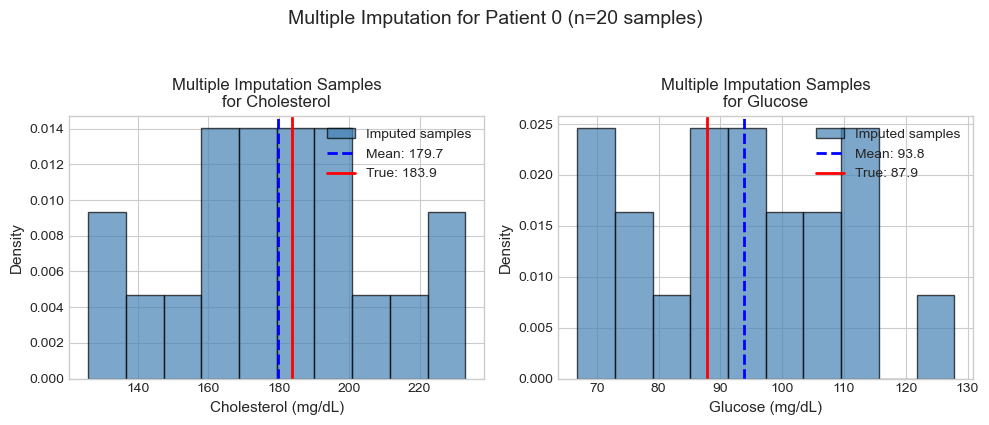

In [19]:
# Visualize multiple imputations
if len(hidden_idx) > 0:
    fig, axes = plt.subplots(1, len(hidden_idx), figsize=(5*len(hidden_idx), 4))
    if len(hidden_idx) == 1:
        axes = [axes]
    
    for i, (idx, ax) in enumerate(zip(hidden_idx, axes)):
        samples = imputations[:, idx]
        true_val = complete_data[patient_idx, idx]
        
        # Histogram of samples
        ax.hist(samples, bins=10, density=True, alpha=0.7, color='steelblue', 
                edgecolor='black', label='Imputed samples')
        
        # Mark posterior mean
        ax.axvline(samples.mean(), color='blue', linestyle='--', linewidth=2,
                   label=f'Mean: {samples.mean():.1f}')
        
        # Mark true value
        ax.axvline(true_val, color='red', linestyle='-', linewidth=2,
                   label=f'True: {true_val:.1f}')
        
        ax.set_xlabel(f'{variable_names[idx]} ({variable_units[idx]})', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'Multiple Imputation Samples\nfor {variable_names[idx]}', fontsize=12)
        ax.legend()
    
    plt.suptitle(f'Multiple Imputation for Patient {patient_idx} (n={n_imp} samples)', 
                 fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()

## Summary

### Key Takeaways from PML 3.2.5:

1. **Missing value imputation** uses the conditional distribution:
   $$p(\mathbf{y}_h | \mathbf{y}_v) = \mathcal{N}(\boldsymbol{\mu}_{h|v}, \boldsymbol{\Sigma}_{h|v})$$

2. **The posterior mean** $\boldsymbol{\mu}_{h|v}$ is our best guess for missing values:
   - It minimizes expected squared error
   - It leverages correlations between variables

3. **The posterior covariance** $\boldsymbol{\Sigma}_{h|v}$ gives uncertainty:
   - We can compute confidence intervals
   - Uncertainty is lower when observed variables are highly correlated with missing ones

4. **MVN imputation outperforms simple methods** (like mean imputation):
   - It uses the correlation structure of the data
   - It adapts to each patient's observed values

5. **Multiple imputation** provides more robust uncertainty:
   - Draw samples from the posterior instead of just using the mean
   - Propagate uncertainty to downstream analyses

### Clinical Application:

- Missing lab results are common in healthcare data
- MVN imputation can fill gaps using known correlations between measurements
- Uncertainty quantification helps clinicians know when to order additional tests
- This approach assumes the data is **missing at random** (MAR), which may not always hold